## Iterative Workflows

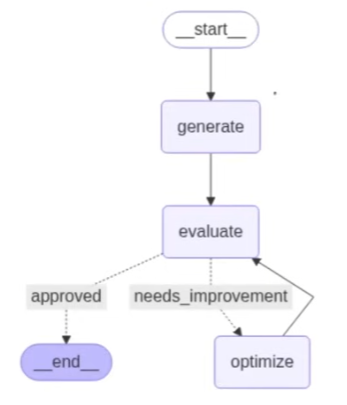

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
import operator

load_dotenv()

generator_llm = ChatOllama(
    model="llama3",  # or any model you have pulled
    temperature=0
) 
evaluator_llm = ChatOllama(
    model="llama3",  # or any model you have pulled
    temperature=0
) 
optimizer_llm = ChatOllama(
    model="llama3",  # or any model you have pulled
    temperature=0
) 

c:\Users\HP\Documents\Coding journeys\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="Constructive feedback for the tweet.")

In [6]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [2]:
# State
class TweetState(TypedDict):
    topic : str
    tweet : str
    evaluation : Literal['approved', 'needs_improvement']
    feedback : str
    iteration : int
    max_iteration : int
    

In [10]:
def generate_tweet(state : TweetState):
    # Prompt
    message = [
        SystemMessage(content = 'You are a funny and clever Twitter/X Influencer.'),
        HumanMessage(content = f"""
        Write a short, original and hilarious tweet on the topic "{state['topic']}".
        
        Rules :
        - Do not use question asnwer format
        - Max 200 characters
        - Use observational humaour, irony, sarcasm or cultural references
        - Think in meme logiv, punchlines,  or relatable takes
        - use simple day to day English
        - This is version {state['iteration'] + 1}.
                     """)
    ]
    
    # send generator_llm
    response = generator_llm.invoke(message).content
    
    return {'tweet' : response}

def evaluate_tweet(state : TweetState):
    # prompt
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['tweet']}"

    Use the criteria below to evaluate the tweet:

    1. Originality - Is this fresh, or have you seen it a hundred times before?
    2. Humor - Did it genuinely make you smile, laugh, or chuckle?
    3. Punchiness - Is it short, sharp, and scroll-stopping?
    4. Virality Potential - Would people retweet or share it?
    5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

    ### Respond ONLY in structured format:
    - evaluation: "approved" or "needs_improvement"
    - feedback: One paragraph explaining the strengths and weaknesses
    """)
    ]
    
    response = structured_evaluator_llm.invoke(messages)
    
    return {
        'evaluation' : response.evaluation,
        'feedback' : response.feedback
    }

def optimize_tweet(state : TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]
    
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1
    
    return {
        'tweet' : response,
        'iteration' : iteration
    }
    
def route_evaluation(state : TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [11]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved' : END, 'needs_improvement' : 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()


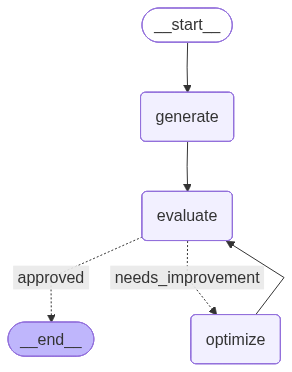

In [12]:
workflow

In [14]:
initial_state = {
    'topic' : 'Indian railways',
    'iteration' : 1,
    'max_iteration' : 5
}

workflow.invoke(initial_state)

{'topic': 'Indian railways',
 'tweet': '"Just rode the Indian railways and I\'m convinced the only thing more crowded than the trains are my aunties\' WhatsApp groups #IndianRailways #AuntyNetwork"',
 'evaluation': 'approved',
 'feedback': "This tweet is a winner! The original comparison between Indian railways and aunties' WhatsApp groups is fresh, relatable, and genuinely funny. The use of hashtags adds to its virality potential, making it likely to be shared and retweeted. The format is well-executed, with a clear and concise statement that packs a punch. The only minor critique is that the humor might not appeal to everyone, but overall, this tweet has great chances of going viral.",
 'iteration': 1,
 'max_iteration': 5}